In [4]:
import pandas as pd

from matplotlib import pyplot as plt
import matplotlib.lines as mlines

In [8]:
configs = []
throughput_lst = []
rougleL_lst = []
bert_lst = []

for shallow_exit_layer in [40, 50, 60, 70]:
    for conf_threshold in [0.7, 0.8, 0.9, 0.95]:
        configs.append(f"layer_{shallow_exit_layer}_conf_{conf_threshold}")
        file_name = f"/workspace/xutingl/vattention-ee/outputs_70b/ee_nobatch/req_100_batch_1_layer_{shallow_exit_layer}_conf_{conf_threshold}_eager_copy.csv"
        df = pd.read_csv(file_name)
        throughput_lst.append(df.throughput.mean())
        rougleL_lst.append(df.rougeL.mean())
        bert_lst.append(df.bert_score.mean())

# add off
configs.append("off")
off_file_name = f"/workspace/xutingl/vattention-ee/outputs_70b/ee_nobatch/req_100_batch_1_layer_40_conf_0.7_off_copy.csv"
off_df = pd.read_csv(off_file_name)
throughput_lst.append(off_df.throughput.mean())
rougleL_lst.append(off_df.rougeL.mean())
bert_lst.append(off_df.bert_score.mean())

df = pd.DataFrame({
    "configs": configs,
    "throughput": throughput_lst,
    "rougeL": rougleL_lst,
    "bert": bert_lst
})
df

,configs,throughput,rougeL,bert
0,layer_40_conf_0.7,21.955927,0.151372,0.849419
1,layer_40_conf_0.8,21.923487,0.147063,0.848307
2,layer_40_conf_0.9,21.805843,0.157351,0.851538
3,layer_40_conf_0.95,21.652565,0.153273,0.850004
4,layer_50_conf_0.7,26.458563,0.103029,0.797522
5,layer_50_conf_0.8,25.602017,0.111888,0.801912
6,layer_50_conf_0.9,24.237705,0.117300,0.817708
7,layer_50_conf_0.95,23.475574,0.132842,0.829548
8,layer_60_conf_0.7,27.007428,0.047239,0.734565
9,layer_60_conf_0.8,26.406611,0.073709,0.759626


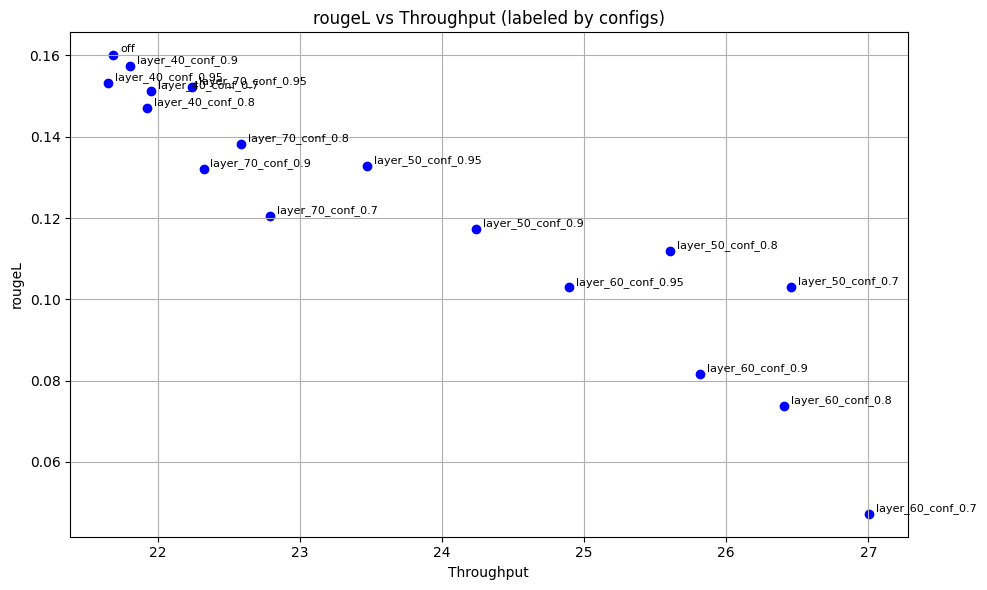

In [9]:
# rougeL vs throughput
plt.figure(figsize=(10, 6))
plt.scatter(df['throughput'], df['rougeL'], color='b')

# Annotate each point with its config label
for i, row in df.iterrows():
    plt.annotate(row['configs'], (row['throughput'], row['rougeL']), fontsize=8, xytext=(5,2), textcoords='offset points')

plt.xlabel('Throughput')
plt.ylabel('rougeL')
plt.title('rougeL vs Throughput (labeled by configs)')
plt.grid(True)
plt.tight_layout()
plt.show()


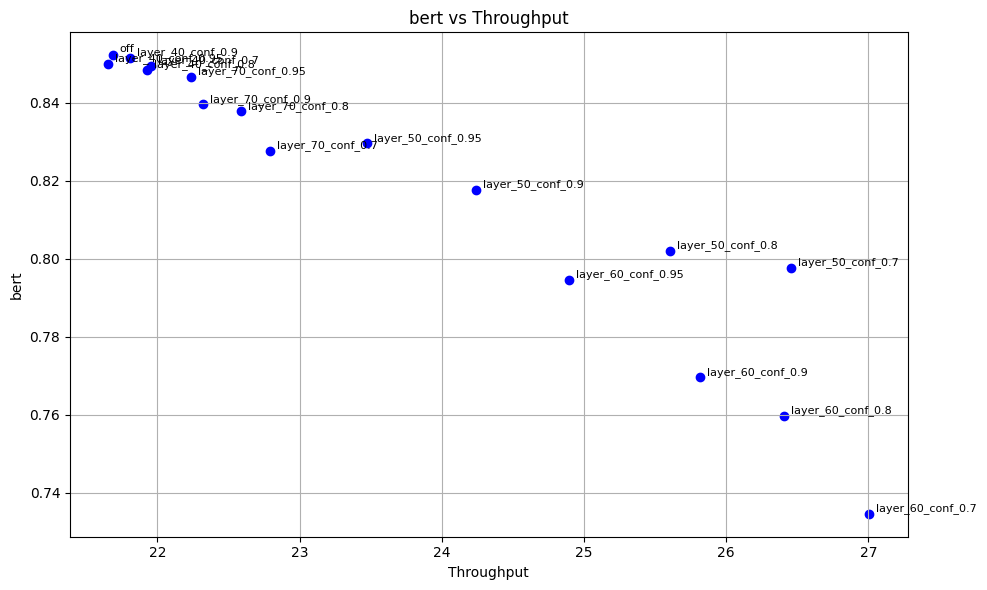

In [10]:
# bert vs throughput
plt.figure(figsize=(10, 6))
plt.scatter(df['throughput'], df['bert'], color='b')

# Annotate each point with its config label
for i, row in df.iterrows():
    plt.annotate(row['configs'], (row['throughput'], row['bert']), fontsize=8, xytext=(5,2), textcoords='offset points')

plt.xlabel('Throughput')
plt.ylabel('bert')
plt.title('bert vs Throughput')
plt.grid(True)
plt.tight_layout()
plt.show()